In [99]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import sys
sys.path.append('../')
from utils import get_train_results, add_scatterplot, add_history_plot
from scipy import stats
import numpy as np

plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rcParams["text.usetex"] = False

import warnings
warnings.filterwarnings('ignore')

model_name = 'cnn'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


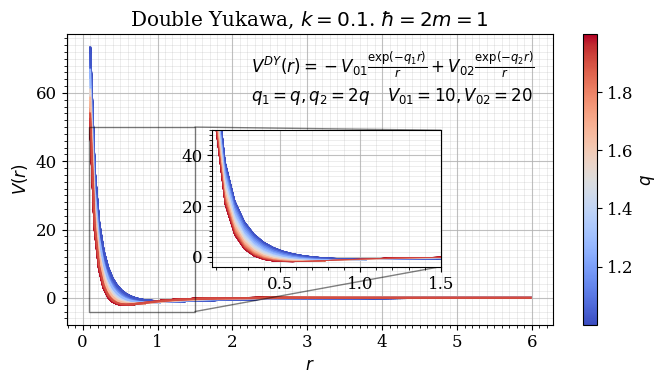

In [129]:
# dYukawa = np.genfromtxt(f"../../data/double_yukawa/k=0.1.txt")
dYukawa = np.load(f"output/data_k0.1.pkl", allow_pickle=True)[["V", "q"]]
r = np.arange(0.1, 6, 0.06)

figPot, axPot = plt.subplots(figsize=(7,4))

axPot.set_title("Double Yukawa, $k=0.1$. $\\hbar=2m=1$")

axPot.set_xlabel("$r$")
axPot.set_ylabel("$V(r)$")

axPot.xaxis.set_minor_locator(AutoMinorLocator(10))
axPot.yaxis.set_minor_locator(AutoMinorLocator(10))

# cmap = plt.get_cmap("gnuplot")
cmap = plt.get_cmap("coolwarm")
norm = plt.Normalize(dYukawa["q"].min(), dYukawa["q"].max())

for V, q in zip(dYukawa["V"], dYukawa["q"]):
    axPot.plot(r, V, c=cmap(norm(q)))

# axPot.annotate(f"$V^{{\\text{{DY}}}} = -V_{{01}}\\frac{{\\exp(-q_1 r)}}{{r}}$", xy=(0.6,0.9), xycoords='axes fraction')
axPot.annotate(f"$V^{{DY}}(r) = -V_{{01}}\\frac{{\\exp(-q_1 r)}}{{r}} + V_{{02}}\\frac{{\\exp(-q_2 r)}}{{r}}$", xy=(0.38,0.87), xycoords='axes fraction')
axPot.annotate(f"$q_1=q, q_2=2q$", xy=(0.38,0.77), xycoords='axes fraction')
axPot.annotate(f"$V_{{01}}=10, V_{{02}}=20$", xy=(0.66,0.77), xycoords='axes fraction')

axPot.grid(which="major", axis="both", lw=0.8, alpha=0.8)
axPot.grid(which="minor", axis="both", lw=0.4, alpha=0.4)

x1, x2, y1, y2 = 0.08, 1.5, -4, 50
axins = axPot.inset_axes(
    [0.3, 0.2, 0.47, 0.47],
    xlim=(x1, x2), ylim=(y1, y2))

axins.xaxis.set_minor_locator(AutoMinorLocator(5))
axins.yaxis.set_minor_locator(AutoMinorLocator(10))

for V, q in zip(dYukawa["V"], dYukawa["q"]):
    axins.plot(r, V, c=cmap(norm(q)), lw=0.6)

axins.grid(which="major", axis="both", lw=0.8, alpha=0.8)
axins.grid(which="minor", axis="both", lw=0.4, alpha=0.4)

axPot.indicate_inset_zoom(axins, edgecolor="black")

figPot.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axPot, label="$q$")

figPot.tight_layout()

## Load data

In [2]:
y_test_k01, predictions_k01, history_k01 = get_train_results(model_name, "k0.1")
y_test_k05, predictions_k05, history_k05 = get_train_results(model_name, "k0.5")
y_test_k5, predictions_k5, history_k5 = get_train_results(model_name, "k5.0")
y_test_k10, predictions_k10, history_k10 = get_train_results(model_name, "k10.0")

In [3]:
# import numpy as np 
# def mean_absolute_percentage_error(y_true, y_pred): 
#     return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# v1 = mean_absolute_percentage_error(y_test_k01, predictions_k01)
# v2 = mean_absolute_percentage_error(y_test_k05, predictions_k05)
# v3 = mean_absolute_percentage_error(y_test_k5, predictions_k5)
# v4 = mean_absolute_percentage_error(y_test_k10, predictions_k10)
# print(v1,v2,v3,v4)

## Plots

k=0.1: pearson coefs= 0.9999999065968961
k=0.5: pearson coefs= 0.9999951002766998
k=5.0: pearson coefs= 0.9999993651808508
k=10.0: pearson coefs= 0.9999994617312096


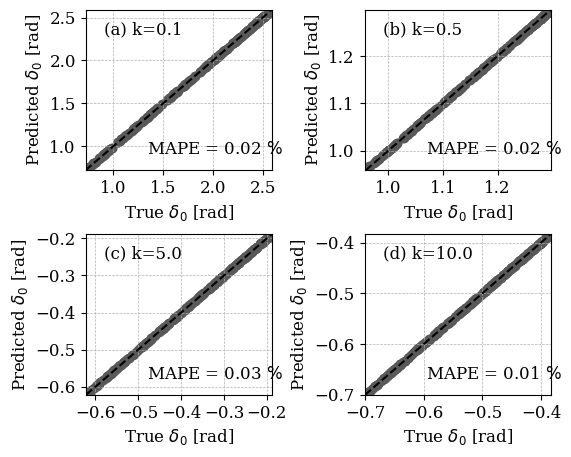

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(6, 5))

print('k=0.1: pearson coefs=', stats.pearsonr(y_test_k01, predictions_k01)[0])
add_scatterplot(axs, (0, 0), y_test_k01, predictions_k01, str_label='(a) k=0.1', nticks=6)

print('k=0.5: pearson coefs=', stats.pearsonr(y_test_k05, predictions_k05)[0])
add_scatterplot(axs, (0, 1), y_test_k05, predictions_k05, str_label='(b) k=0.5', nticks=6)

print('k=5.0: pearson coefs=', stats.pearsonr(y_test_k5, predictions_k5)[0])
add_scatterplot(axs, (1, 0), y_test_k5, predictions_k5, str_label='(c) k=5.0', nticks=6)

print('k=10.0: pearson coefs=', stats.pearsonr(y_test_k10, predictions_k10)[0])
add_scatterplot(axs, (1, 1), y_test_k10, predictions_k10, str_label='(d) k=10.0', nticks=6)

#plt.tight_layout()
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.4)
#plt.savefig('output/'+model_name+'/double_yukawa_scatter.pdf', format='pdf')
plt.show()

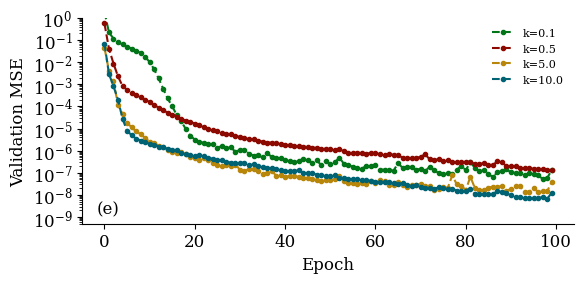

In [5]:
plt.style.use('seaborn-dark-palette') 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  

fig, ax = plt.subplots(figsize=(6, 3))
#plt.axes(yscale='log')

ax.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
ax.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
ax.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
ax.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])

#ax2 = fig.add_axes([0.4, 0.5, 0.35, 0.3])
#ax2.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
#ax2.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
#ax2.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
#ax2.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])
#ax2.set_xlim(0, 3)
#ax2.set_ylim(0, 0.05)
#ax2.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
#ax2.set_ylabel('MSE')
#ax2.set_xlabel('Epoch')

ax.set_ylabel('Validation MSE')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right', frameon=False)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)

ax.set_yscale('log')
import matplotlib 
import numpy 
y_major = matplotlib.ticker.LogLocator(base=10.0, numticks=20)
ax.yaxis.set_major_locator(y_major)
y_minor = matplotlib.ticker.LogLocator(base=10.0, subs=numpy.arange(1.0, 10.0) * 0.1, numticks=20)
ax.yaxis.set_minor_locator(y_minor)
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_ylim(5e-10, 1)

ax.text(0.03, 0.05, '(e)', transform=ax.transAxes, size=12)

plt.tight_layout()
plt.grid(False)
plt.savefig('output/'+model_name+'/double_yukawa_history_log.pdf', format='pdf')
plt.show()


## Model transferability

In [6]:

# fig, axs = plt.subplots(4, 2, figsize=(6, 10))

# model_name = 'cnn'

# # k=0.1
# dset_name = 'k0.1'
# predictions = np.load('output/predict_yukawa/predictions_%s.npy'%dset_name)
# y_test = np.load('output/predict_yukawa/y_test_%s.npy'%dset_name)
# print('k=0.1: pearson coefs=', stats.pearsonr(y_test, predictions)[0])

# add_subplot(axs, 0, y_test, predictions, str_labels=('(a) k=0.1', '(b)'), nticks=6)

# # k=0.5
# dset_name = 'k0.5'
# predictions = np.load('output/predict_yukawa/predictions_%s.npy'%dset_name)
# y_test = np.load('output/predict_yukawa/y_test_%s.npy'%dset_name)
# print('k=0.5: pearson coefs=', stats.pearsonr(y_test, predictions)[0])

# add_subplot(axs, 1, y_test, predictions, str_labels=('(c) k=0.5', '(d)'), nticks=6)


# # k=5.0
# dset_name = 'k5.0'
# predictions = np.load('output/predict_yukawa/predictions_%s.npy'%dset_name)
# y_test = np.load('output/predict_yukawa/y_test_%s.npy'%dset_name)
# print('k=5.0: pearson coefs=', stats.pearsonr(y_test, predictions)[0])

# add_subplot(axs, 2, y_test, predictions, str_labels=('(e) k=0.1', '(f)'), nticks=6)

# # k=10.0
# dset_name = 'k10.0'
# predictions = np.load('output/predict_yukawa/predictions_%s.npy'%dset_name)
# y_test = np.load('output/predict_yukawa/y_test_%s.npy'%dset_name)
# print('k=10.0: pearson coefs=', stats.pearsonr(y_test, predictions)[0])

# add_subplot(axs, 3, y_test, predictions, str_labels=('(g) k=0.1', '(h)'), nticks=6)

# plt.tight_layout()
# plt.show()

In [7]:
model_name = 'rnn'

In [8]:
y_test_k01, predictions_k01, history_k01 = get_train_results(model_name, "k0.1")
y_test_k05, predictions_k05, history_k05 = get_train_results(model_name, "k0.5")
y_test_k5, predictions_k5, history_k5 = get_train_results(model_name, "k5.0")
y_test_k10, predictions_k10, history_k10 = get_train_results(model_name, "k10.0")

k=0.1: pearson coefs= 0.9999993960016245
k=0.5: pearson coefs= 0.9999953840514453
k=5.0: pearson coefs= 0.9999993316607816
k=10.0: pearson coefs= 0.9999977506951885


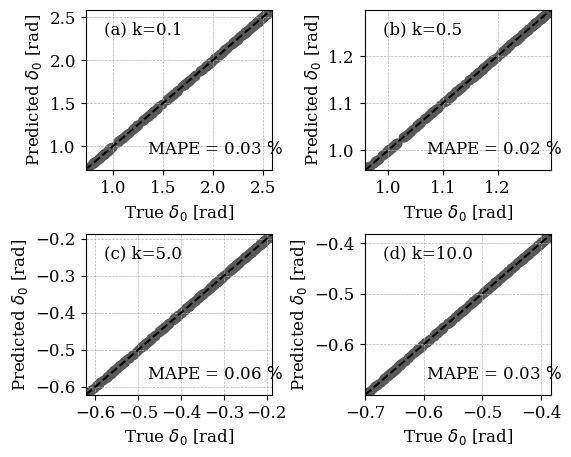

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(6, 5))

print('k=0.1: pearson coefs=', stats.pearsonr(y_test_k01, predictions_k01)[0])
add_scatterplot(axs, (0, 0), y_test_k01, predictions_k01, str_label='(a) k=0.1', nticks=6)

print('k=0.5: pearson coefs=', stats.pearsonr(y_test_k05, predictions_k05)[0])
add_scatterplot(axs, (0, 1), y_test_k05, predictions_k05, str_label='(b) k=0.5', nticks=6)

print('k=5.0: pearson coefs=', stats.pearsonr(y_test_k5, predictions_k5)[0])
add_scatterplot(axs, (1, 0), y_test_k5, predictions_k5, str_label='(c) k=5.0', nticks=6)

print('k=10.0: pearson coefs=', stats.pearsonr(y_test_k10, predictions_k10)[0])
add_scatterplot(axs, (1, 1), y_test_k10, predictions_k10, str_label='(d) k=10.0', nticks=6)

#plt.tight_layout()
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.4)
plt.savefig('output/'+model_name+'/double_yukawa_scatter.pdf', format='pdf')
plt.show()

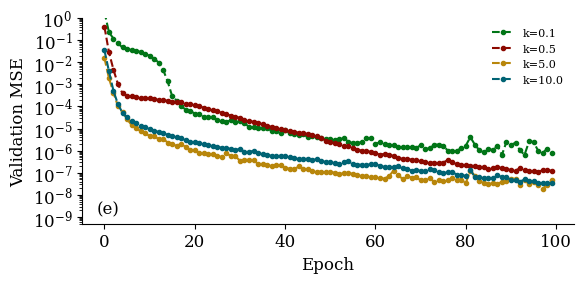

In [10]:
plt.style.use('seaborn-dark-palette') 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  

fig, ax = plt.subplots(figsize=(6, 3))
#plt.axes(yscale='log')

ax.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
ax.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
ax.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
ax.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])

#ax2 = fig.add_axes([0.4, 0.5, 0.35, 0.3])
#ax2.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
#ax2.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
#ax2.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
#ax2.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])
#ax2.set_xlim(0, 3)
#ax2.set_ylim(0, 0.05)
#ax2.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
#ax2.set_ylabel('MSE')
#ax2.set_xlabel('Epoch')

ax.set_ylabel('Validation MSE')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right', frameon=False)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)

ax.set_yscale('log')
import matplotlib 
import numpy 
y_major = matplotlib.ticker.LogLocator(base=10.0, numticks=20)
ax.yaxis.set_major_locator(y_major)
y_minor = matplotlib.ticker.LogLocator(base=10.0, subs=numpy.arange(1.0, 10.0) * 0.1, numticks=20)
ax.yaxis.set_minor_locator(y_minor)
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_ylim(5e-10, 1)

ax.text(0.03, 0.05, '(e)', transform=ax.transAxes, size=12)

plt.tight_layout()
plt.grid(False)
plt.savefig('output/'+model_name+'/double_yukawa_history_log.pdf', format='pdf')
plt.show()


In [11]:
model_name = 'cnn_rnn_hybrid'

In [12]:
y_test_k01, predictions_k01, history_k01 = get_train_results(model_name, "k0.1")
y_test_k05, predictions_k05, history_k05 = get_train_results(model_name, "k0.5")
y_test_k5, predictions_k5, history_k5 = get_train_results(model_name, "k5.0")
y_test_k10, predictions_k10, history_k10 = get_train_results(model_name, "k10.0")

k=0.1: pearson coefs= 0.9999997422477095
k=0.5: pearson coefs= 0.9999762285402397
k=5.0: pearson coefs= 0.999999565147952
k=10.0: pearson coefs= 0.9999989827157904


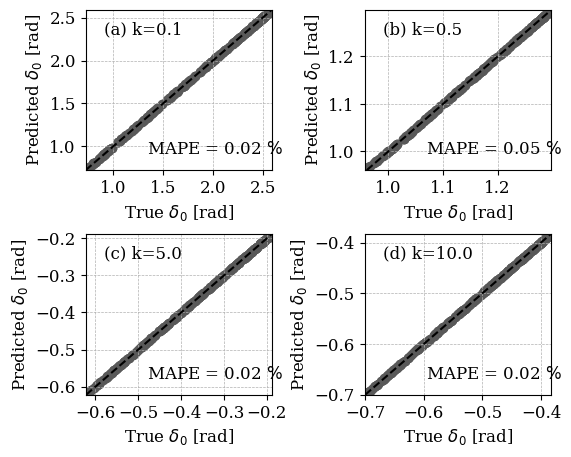

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(6, 5))

print('k=0.1: pearson coefs=', stats.pearsonr(y_test_k01, predictions_k01)[0])
add_scatterplot(axs, (0, 0), y_test_k01, predictions_k01, str_label='(a) k=0.1', nticks=6)

print('k=0.5: pearson coefs=', stats.pearsonr(y_test_k05, predictions_k05)[0])
add_scatterplot(axs, (0, 1), y_test_k05, predictions_k05, str_label='(b) k=0.5', nticks=6)

print('k=5.0: pearson coefs=', stats.pearsonr(y_test_k5, predictions_k5)[0])
add_scatterplot(axs, (1, 0), y_test_k5, predictions_k5, str_label='(c) k=5.0', nticks=6)

print('k=10.0: pearson coefs=', stats.pearsonr(y_test_k10, predictions_k10)[0])
add_scatterplot(axs, (1, 1), y_test_k10, predictions_k10, str_label='(d) k=10.0', nticks=6)

#plt.tight_layout()
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.4)
#plt.savefig('output/'+model_name+'/double_yukawa_scatter.pdf', format='pdf')
plt.show()

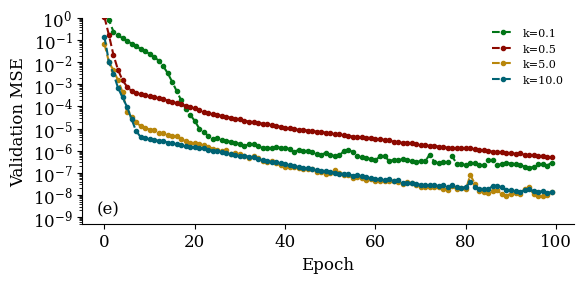

In [14]:
plt.style.use('seaborn-dark-palette') 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  

fig, ax = plt.subplots(figsize=(6, 3))
#plt.axes(yscale='log')

ax.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
ax.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
ax.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
ax.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])

#ax2 = fig.add_axes([0.4, 0.5, 0.35, 0.3])
#ax2.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
#ax2.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
#ax2.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
#ax2.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])
#ax2.set_xlim(0, 3)
#ax2.set_ylim(0, 0.05)
#ax2.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
#ax2.set_ylabel('MSE')
#ax2.set_xlabel('Epoch')

ax.set_ylabel('Validation MSE')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right', frameon=False)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)

ax.set_yscale('log')
import matplotlib 
import numpy 
y_major = matplotlib.ticker.LogLocator(base=10.0, numticks=20)
ax.yaxis.set_major_locator(y_major)
y_minor = matplotlib.ticker.LogLocator(base=10.0, subs=numpy.arange(1.0, 10.0) * 0.1, numticks=20)
ax.yaxis.set_minor_locator(y_minor)
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_ylim(5e-10, 1)

ax.text(0.03, 0.05, '(e)', transform=ax.transAxes, size=12)

plt.tight_layout()
plt.grid(False)
plt.savefig('output/'+model_name+'/double_yukawa_history_log.pdf', format='pdf')
plt.show()
